<a href="https://colab.research.google.com/github/lolndo/Basic_Networks3/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%D0%A1%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D0%B5_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8_%D0%94%D0%97_Pro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Используя датасет "Пассажиры автобуса", создайте нейронную сеть для решения задачи классификации пассажиров на входящих и выходящих.

Добейтесь точности работы модели выше 90% на проверочной выборке

### Загрузка данных


In [1]:
# загрузка библиотек

# методы для отрисовки изображений
from PIL import Image

# Для отрисовки графиков
import matplotlib.pyplot as plt

# Для генерации случайных чисел
import random

# Библиотека работы с массивами
import numpy as np

# Для работы с файлами
import os

# импортируем модуль для загрузки данных
import gdown

# для разделения выборок
from sklearn.model_selection import train_test_split

# для создания сети
from tensorflow.keras.models import Sequential

# для создания слоев
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization

# для работы с изображениями
from tensorflow.keras.preprocessing import image

# оптимизатор
from tensorflow.keras.optimizers import Adam

# модуль для отсчета времени
import time

In [2]:
# загрузка датасета, укажем путь к базе в Google Drive, база в виде .zip-архива
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip', None, quiet=True)

# Распакуем архив в директорию 'content/bus'
!unzip -q "bus.zip" -d /content/bus

# Папка с папками картинок, рассортированных по категориям
IMAGE_PATH = '/content/bus/'

# Получение списка папок, находящемуся по адресу в скобках
os.listdir(IMAGE_PATH)

['Входящий', 'Выходящий']

In [3]:
# Определение списка имен классов
CLASS_LIST = sorted(os.listdir(IMAGE_PATH))

# Определение количества классов
CLASS_COUNT = len(CLASS_LIST)

# Проверка результата
print(f'Количество классов: {CLASS_COUNT}, метки классов: {CLASS_LIST}')

Количество классов: 2, метки классов: ['Входящий', 'Выходящий']


In [4]:
# Получения списка файлов для каждого класса

for cls in CLASS_LIST:
    print(cls, ':', os.listdir(f'{IMAGE_PATH}{cls}/'))

Входящий : ['06107.jpg', '01128.jpg', '01136.jpg', '01866.jpg', '01329.jpg', '02688.jpg', '03676.jpg', '03718.jpg', '00704.jpg', '00595.jpg', '00782.jpg', '05392.jpg', '05176.jpg', '03952.jpg', '03814.jpg', '00857.jpg', '05469.jpg', '03877.jpg', '05361.jpg', '00282.jpg', '06463.jpg', '01916.jpg', '00551.jpg', '03448.jpg', '05942.jpg', '05849.jpg', '04508.jpg', '05858.jpg', '02556.jpg', '05552.jpg', '06239.jpg', '04228.jpg', '05689.jpg', '05799.jpg', '02203.jpg', '00862.jpg', '00851.jpg', '04126.jpg', '02288.jpg', '02723.jpg', '02420.jpg', '03880.jpg', '00896.jpg', '01247.jpg', '06229.jpg', '04738.jpg', '00253.jpg', '06044.jpg', '06158.jpg', '04084.jpg', '05014.jpg', '01217.jpg', '02300.jpg', '06258.jpg', '06401.jpg', '06185.jpg', '01583.jpg', '05611.jpg', '01806.jpg', '06274.jpg', '05120.jpg', '00304.jpg', '04902.jpg', '04041.jpg', '00700.jpg', '04050.jpg', '01800.jpg', '02222.jpg', '01805.jpg', '03041.jpg', '02281.jpg', '05755.jpg', '02927.jpg', '01539.jpg', '06143.jpg', '04268.jpg', 

Отобразим визуально для примера по одному изображению из каждого класса (при помощи функции `.imshow()` из модуля `matplotlib.pyplot`):

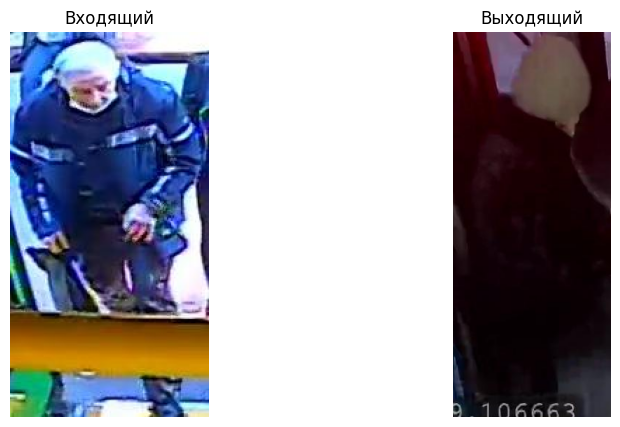

In [6]:
# Создание заготовки для изображений всех классов
fig, axs = plt.subplots(1, CLASS_COUNT, figsize=(10, 5))

# Для всех номеров классов:
for i in range(CLASS_COUNT):

    # Формирование пути к папке содержимого класса
    car_path = f'{IMAGE_PATH}{CLASS_LIST[i]}/'

    # Выбор случайного фото из i-го класса
    img_path = car_path + random.choice(os.listdir(car_path))

    # Отображение фотографии (подробнее будет объяснено далее)
    axs[i].set_title(CLASS_LIST[i])
    axs[i].imshow(Image.open(img_path))
    axs[i].axis('off')

# Отрисовка всего полотна
plt.show()

In [7]:
data_files = []                           # Cписок путей к файлам картинок
data_labels = []                          # Список меток классов, соответствующих файлам

for class_label in range(CLASS_COUNT):    # Для всех классов по порядку номеров (их меток)
    class_name = CLASS_LIST[class_label]  # Выборка имени класса из списка имен
    class_path = IMAGE_PATH + class_name  # Формирование полного пути к папке с изображениями класса
    class_files = os.listdir(class_path)  # Получение списка имен файлов с изображениями текущего класса
    print(f'Размер класса {class_name} составляет {len(class_files)} фото')

    # Добавление к общему списку всех файлов класса с добавлением родительского пути
    data_files += [f'{class_path}/{file_name}' for file_name in class_files]

    # Добавление к общему списку меток текущего класса - их ровно столько, сколько файлов в классе
    data_labels += [class_label] * len(class_files)

print()
print('Общий размер базы для обучения:', len(data_labels))

Размер класса Входящий составляет 6485 фото
Размер класса Выходящий составляет 2596 фото

Общий размер базы для обучения: 9081


In [ ]:
# ваше решение

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


df = pd.DataFrame({'filename': data_files, 'class': data_labels})
df['class'] = df['class'].astype(str)

#Разделение на train/val
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['class'])

In [18]:
IMG_SIZE = (100, 100)
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df, x_col='filename', y_col='class',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    val_df, x_col='filename', y_col='class',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

base_model = MobileNetV2(input_shape=(100,100,3), include_top=False, weights='imagenet')
base_model.trainable = False   # заморозка предобученных весов

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

total = len(data_labels)
class_counts = [len(os.listdir(f'{IMAGE_PATH}{cls}/')) for cls in CLASS_LIST]
class_weight = {0: total / (2 * class_counts[0]), 1: total / (2 * class_counts[1])}

Found 7264 validated image filenames belonging to 2 classes.
Found 1817 validated image filenames belonging to 2 classes.


/tmp/ipykernel_21371/2382415739.py:25: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(100,100,3), include_top=False, weights='imagenet')


In [19]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=10,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    class_weight=class_weight,
    callbacks=[early_stop]
)

Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 118s 978ms/step - accuracy: 0.7249 - loss: 0.5428 - val_accuracy: 0.8024 - val_loss: 0.3674
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 107s 938ms/step - accuracy: 0.8407 - loss: 0.3447 - val_accuracy: 0.8641 - val_loss: 0.2799
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 109s 959ms/step - accuracy: 0.8640 - loss: 0.2943 - val_accuracy: 0.8910 - val_loss: 0.2324
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 142s 957ms/step - accuracy: 0.8899 - loss: 0.2504 - val_accuracy: 0.9119 - val_loss: 0.2028
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 110s 967ms/step - accuracy: 0.8922 - loss: 0.2323 - val_accuracy: 0.9020 - val_loss: 0.2156
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 110s 961ms/step - accuracy: 0.9074 - loss: 0.2130 - val_accuracy: 0.9059 - val_loss: 0.2076
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 141s 945ms/step - accuracy: 0.9115 - loss: 0.2021 - val_accuracy: 0.9152 - val_loss: 0.1914
Epoch 8/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 108s 944ms/step - accuracy: 0.9210 -

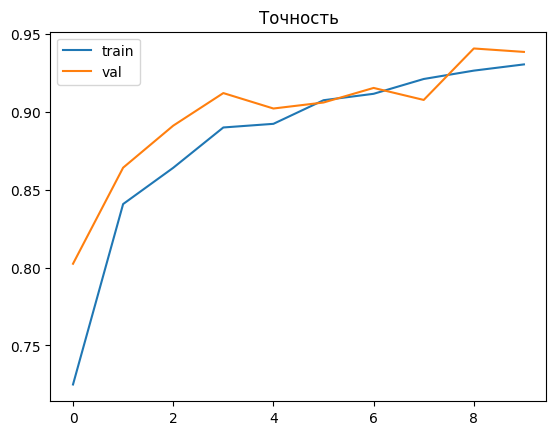

Максимальная точность на проверке: 94.06%


In [20]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend(); plt.title('Точность'); plt.show()

print(f'Максимальная точность на проверке: {max(history.history["val_accuracy"]):.2%}')